## Máster en Big Data y Data Science

### Metodologías de gestión y diseño de proyectos de big data

#### AP2 - Modelado y evaluación

---

En esta libreta se realiza la experimentación para la generación del modelo de predicción objetivo del proyecto y la evaluación del mismo.
La versión del dataset a utilizar es la obtenida a partir de las operaciones de transformación.

**Nota:** esta libreta corresponde a un MVP metodológico. Quedan deliberadamente fuera de su alcance las prácticas de DataOps/MLOps (versionado y registro de experimentos, pipelines automatizados de reentrenamiento, despliegue, monitoreo, etc.), que forman parte del trabajo a desarrollar en la práctica de la materia.

In [1]:
# Se importan las librerías necesarias y se suprimen las advertencias
import pandas as pd
import matplotlib.pyplot as plt
import warnings

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.dummy import DummyClassifier

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score

warnings.filterwarnings('ignore',category=FutureWarning)
warnings.filterwarnings('ignore',category=UserWarning)

In [2]:
# Lectura de los datos
df = pd.read_csv('../data/processed/datos_integrados.csv')
df.head(5)

,categoria_producto,canal_compra,plataforma,texto_resena,tiempo_respuesta_horas,problema_resuelto,reclamo_formal,importe_compra,sentimiento,edad,genero,ciudad,antiguedad_cliente_meses,longitud_resena,cantidad_palabras_resena,tiempo_respuesta_dias
0,Deportes,Online,Flipkart,El envío fue rápido y el colchoneta llegó en p...,4.9,Sí,No,22738.67,Positivo,18.0,Masculino,Mendoza,5,82,13,0.204167
1,Calzado,Online,Flipkart,"El sandalias es tal cual la descripción, estoy...",5.1,Sí,No,42589.72,Positivo,18.0,Otro,San Miguel de Tucumán,61,76,13,0.212500
2,Electrónica,Online,Meesho,"Muy conforme con la compra, la calidad del par...",4.3,Sí,No,29640.40,Positivo,29.0,Masculino,Salta,3,65,12,0.179167
3,Hogar,Online,Falabella,Tuve varios problemas con el lámpara y el sopo...,6.7,Sí,No,28231.19,Neutral,61.0,Femenino,Santa Fe,73,107,18,0.279167
4,Deportes,Offline,Zepto,"Excelente botella deportiva, superó mis expect...",12.5,Sí,No,14683.00,Positivo,46.0,Masculino,Salta,61,82,12,0.520833


In [3]:
def reporte_descripcion_dataset(df):
    columnas = df.columns
    print("Columnas del dataset:\n")
    for col in columnas:
        print(col)
    print(f"\nCantidad de filas: {df.shape[0]}")

print("Descripción del dataset 'datos_integrados.csv':\n")
reporte_descripcion_dataset(df)

Descripción del dataset 'datos_integrados.csv':

Columnas del dataset:

categoria_producto
canal_compra
plataforma
texto_resena
tiempo_respuesta_horas
problema_resuelto
reclamo_formal
importe_compra
sentimiento
edad
genero
ciudad
antiguedad_cliente_meses
longitud_resena
cantidad_palabras_resena
tiempo_respuesta_dias

Cantidad de filas: 24934


In [4]:
# Se divide el dataset en variables predictoras y variable objetivo
target = "sentimiento"

features_X = df.drop(columns=[target])
labels_y = df[target]

print("Dimensiones X:", features_X.shape)
print("Dimensiones y:", labels_y.shape)

Dimensiones X: (24934, 15)
Dimensiones y: (24934,)


In [5]:
# Se genera el conjunto de entrenamiento, validación y test con estratificación

# Primero se separa el test final (10%)
X_temp, X_test, y_temp, y_test = train_test_split(
    features_X,
    labels_y,
    test_size=0.10,
    random_state=42,
    stratify=labels_y
)

# Luego se separan train y validation (22% del 90% es aprox. el 20% del total)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.22,
    random_state=42,
    stratify=y_temp
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (17503, 15)
Validation: (4937, 15)
Test: (2494, 15)


In [6]:
# Se identifican las columnas numéricas, categóricas y de texto
# El texto de la reseña se trata por separado, ya que requiere una vectorización específica (TF-IDF)

text_col = "texto_resena"
num_cols = features_X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = [c for c in features_X.select_dtypes(include=["object", "string"]).columns if c != text_col]

print("Numéricas:", num_cols)
print("Categóricas:", cat_cols)
print("Texto:", text_col)

Numéricas: ['tiempo_respuesta_horas', 'importe_compra', 'edad', 'antiguedad_cliente_meses', 'longitud_resena', 'cantidad_palabras_resena', 'tiempo_respuesta_dias']
Categóricas: ['categoria_producto', 'canal_compra', 'plataforma', 'problema_resuelto', 'reclamo_formal', 'genero', 'ciudad']
Texto: texto_resena


In [7]:
# Se verifica la distribución de la variable objetivo en el conjunto de entrenamiento
y_train.value_counts()

sentimiento
Positivo    11293
Negativo     3129
Neutral      3081
Name: count, dtype: int64

### Preprocesamiento y modelo base

Se arma un pipeline de preprocesamiento que combina variables numéricas, categóricas y el texto de la reseña, y se evalúa un modelo base (baseline) como punto de referencia mínimo.

In [8]:
# Se crea un pipeline para preprocesamiento de datos

numeric_transformer = Pipeline([
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# TfidfVectorizer recibe directamente el nombre de la columna (no una lista),
# lo que hace que ColumnTransformer le pase el texto como un arreglo unidimensional
text_transformer = TfidfVectorizer(max_features=300)

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols),
    ("text", text_transformer, text_col)
])

In [9]:
# Se crea un pipeline completo con preprocesamiento y modelo base

baseline = Pipeline([
    ("prep", preprocessor),
    ("model", DummyClassifier(strategy="most_frequent"))
])

baseline.fit(X_train, y_train)

y_pred = baseline.predict(X_val)

print("Baseline accuracy:", accuracy_score(y_val, y_pred))

Baseline accuracy: 0.64533117277699


### Comparación de modelos

In [10]:
# Se definen los modelos a evaluar

modelos = {
    "LogisticRegression": LogisticRegression(max_iter=2000),
    "LinearSVC": LinearSVC(max_iter=5000),
    "KNN": KNeighborsClassifier(),
    "DecisionTree": DecisionTreeClassifier(random_state=42)
}

#############################################################
# TODO: Cambios aplicables: incorporar otros modelos,
# ajuste de hiperparámetros, balanceo de clases, etc.
#############################################################

In [11]:
# Se evalúan los modelos con validación cruzada comparando sus resultados

resultados = []

for nombre, modelo in modelos.items():
    pipeline = Pipeline([
        ("prep", preprocessor),
        ("model", modelo)
    ])

    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=5,
        scoring="accuracy"
    )

    resultados.append({
        "modelo": nombre,
        "accuracy_promedio": scores.mean(),
        "accuracy_desvio": scores.std()
    })

df_resultados = pd.DataFrame(resultados).sort_values("accuracy_promedio", ascending=False)
df_resultados

,modelo,accuracy_promedio,accuracy_desvio
1,LinearSVC,0.866137,0.003385
0,LogisticRegression,0.865109,0.003830
3,DecisionTree,0.810661,0.004008
2,KNN,0.694738,0.005751


Entrenamiento del modelo final

In [12]:
# Se entrena el mejor modelo sobre el conjunto de entrenamiento completo

modelo_final = Pipeline([
    ("prep", preprocessor),
    ("model", LogisticRegression(max_iter=2000))
])

modelo_final.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](3,)","['Negativo','Neutral','Positivo']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['categoria_producto','canal_compra','plataforma',...,'longitud_resena', 'cantidad_palabras_resena','tiempo_respuesta_dias']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are d

In [13]:
# Se evalúan los resultados en el conjunto de validación

y_val_pred = modelo_final.predict(X_val)

print(classification_report(y_val, y_val_pred))

              precision    recall  f1-score   support

    Negativo       0.88      0.91      0.90       882
     Neutral       0.59      0.79      0.68       869
    Positivo       0.97      0.87      0.92      3186

    accuracy                           0.87      4937
   macro avg       0.82      0.86      0.83      4937
weighted avg       0.89      0.87      0.87      4937



In [14]:
# Se evalúan los resultados en el conjunto de test

y_test_pred = modelo_final.predict(X_test)

print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

    Negativo       0.91      0.93      0.92       446
     Neutral       0.62      0.83      0.71       439
    Positivo       0.97      0.88      0.92      1609

    accuracy                           0.88      2494
   macro avg       0.83      0.88      0.85      2494
weighted avg       0.90      0.88      0.88      2494



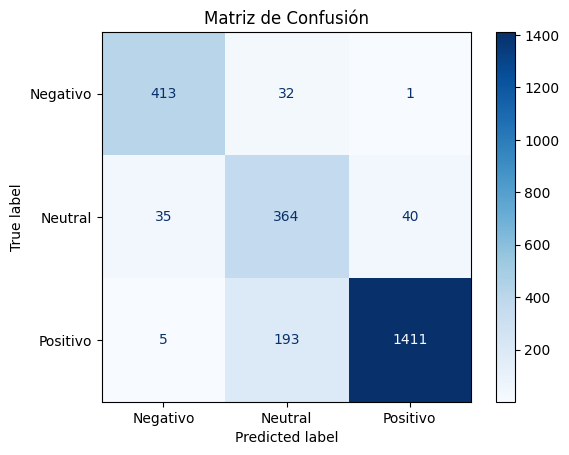

In [15]:
# Se genera una matriz de confusión para el conjunto de test

cm = confusion_matrix(y_test, y_test_pred, labels=modelo_final.classes_)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=modelo_final.classes_)

disp.plot(cmap="Blues")

plt.title("Matriz de Confusión")
plt.show()

Exportación de los resultados de la comparación de modelos

In [16]:
df_resultados.to_csv("resultados_modelos.csv", index=False)